# BÀI THỰC HÀNH 3 (CHƯƠNG 2, PHẦN 2): CANNY EDGE DETECTOR

---

## 📌 BẢNG PHÂN CÔNG & TIẾN ĐỘ 7 THÀNH VIÊN TRONG NHÓM

| STT | Thành viên | Phần phụ trách | Nhiệm vụ chính | Phạm vi code / docs |
| :---: | :--- | :--- | :--- | :--- |
| **1** | **Đức** | **I.1 (a + b) + III.1** | Lý thuyết 5 bước Canny, So sánh Sobel/Laplacian, Đánh giá chất lượng cạnh (Pratt's FOM, PSNR, SSIM). | `docs/plan.md` |
| **2** | **Thọ** | **I.2 (a + b) + III.2** | Phân tích tham số Sigma ($\sigma$), Ngưỡng Low/High, Phương pháp cải thiện hiệu suất Canny. | `docs/plan.md` |
| **3** | **Thông** | **I.3 (a + b + c) + III.3** | Ưu/nhược điểm Canny, Lĩnh vực ứng dụng, Canny cho ảnh màu & So sánh toán tử Sobel/Laplacian/Canny. | `notebook/lab3.ipynb` |
| **4** | **Duy** | **II.1 & II.2 (OpenCV)** | Canny Baseline, Khảo sát Sigma ($1.0 \to 5.0$), Khảo sát Ngưỡng Low/High, Đếm pixel `np.count_nonzero()`. | `notebook/lab3.ipynb` |
| **5** | **Phước** | **II.1 & II.2 (Skimage)** | Thực hành Canny bằng Scikit-image (`skimage.feature.canny` trong `canny_skimage/`), Khảo sát tham số và báo cáo. | `canny_skimage/` & `notebook/lab3.ipynb` |
| **6** | **Vinh** | **II.3 (Đa dạng ảnh)** | Áp dụng Canny trên 3 loại ảnh (Ảnh nhiễu Gaussian, Tương phản thấp, Nhiều chi tiết). | `notebook/lab3.ipynb` |
| **7** | **Huy** | **II.4 + III.4 (Nâng cao)** | Kết hợp Canny với Phân đoạn Contour (Bounding Box), Nhận dạng Hough Transform & Canny cho Video. | `notebook/lab3.ipynb` |

---


## 📖 PHẦN I: TỔNG QUAN NỀN TẢNG LÝ THUYẾT THUẬT TOÁN CANNY

### 1. Chi tiết 5 bước của Thuật toán Canny
1. **Làm mịn bằng Bộ lọc Gaussian 2D (Noise Reduction):**
   $$G(x, y, \sigma) = \frac{1}{2\pi\sigma^2} \exp\left(-\frac{x^2 + y^2}{2\sigma^2}\right)$$
2. **Tính toán Gradient (Magnitude & Orientation):**
   $$M(x, y) = \sqrt{G_x^2 + G_y^2} \approx |G_x| + |G_y|, \quad \theta(x, y) = \arctan\left(\frac{G_y}{G_x}\right)$$
3. **Triệt tiêu phi cực đại (Non-Maximum Suppression - NMS):**
   - Làm tròn góc $\theta(x, y)$ về 4 hướng ($0^\circ, 45^\circ, 90^\circ, 135^\circ$). Làm mỏng đường biên về **1 pixel**.
4. **Lọc ngưỡng kép (Double Thresholding):**
   - Cạnh mạnh ($M \ge T_{\text{high}}$), Cạnh yếu ($T_{\text{low}} \le M < T_{\text{high}}$), Không phải cạnh ($M < T_{\text{low}}$).
5. **Theo dõi cạnh qua liên kết Hysteresis (Edge Tracking by Hysteresis):**
   - Giữ lại pixel cạnh yếu nếu kết nối 8-hướng với ít nhất một pixel Cạnh mạnh.

---


### 💻 PHẦN I.1.b & I.3.a: SO SÁNH CÁC THUẬT TOÁN PHÁT HIỆN CẠNH (THÔNG - TV 3)
So sánh trực tiếp kết quả phát hiện cạnh giữa **Sobel (Đạo hàm bậc 1)**, **Laplacian (Đạo hàm bậc 2)** và **Canny (Tối ưu hóa đa giai đoạn)** trên cùng một ảnh đầu vào.


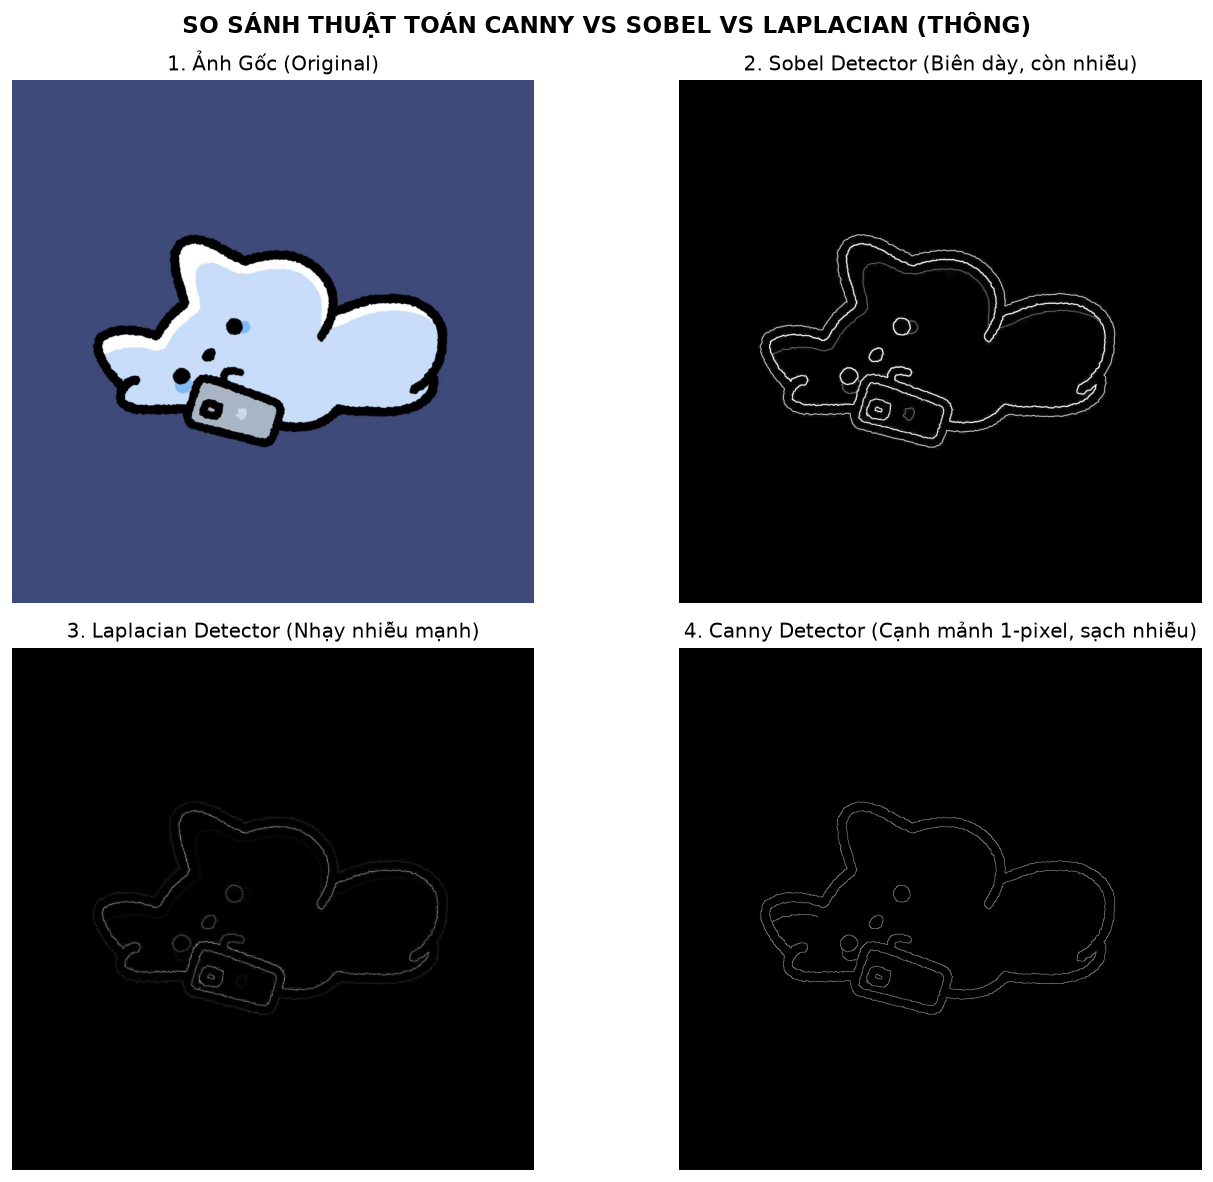

In [1]:
# 1. Sobel Magnitude (Đạo hàm bậc 1)
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = cv2.magnitude(sobelx, sobely)
sobel_res = cv2.convertScaleAbs(sobel_mag)

# 2. Laplacian (Đạo hàm bậc 2)
lap_res = cv2.convertScaleAbs(cv2.Laplacian(gray, cv2.CV_64F))

# 3. Canny Edge Detector
canny_res = cv2.Canny(gray, 100, 200)

fig1 = plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("1. Ảnh Gốc (Original)")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(sobel_res, cmap="gray")
plt.title("2. Sobel Detector (Biên dày, còn nhiễu)")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(lap_res, cmap="gray")
plt.title("3. Laplacian Detector (Nhạy nhiễu mạnh)")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(canny_res, cmap="gray")
plt.title("4. Canny Detector (Cạnh mảnh 1-pixel, sạch nhiễu)")
plt.axis("off")

plt.suptitle("SO SÁNH THUẬT TOÁN CANNY VS SOBEL VS LAPLACIAN (THÔNG)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


📊 **PHÂN TÍCH VÀ ĐÁNH GIÁ KẾT QUẢ SO SÁNH (THÔNG):**
- **Sobel Detector:** Cho đường biên rõ nhưng **dày (3-5 pixels)** do chưa qua lọc NMS. Bản đồ biên còn chứa nhiều vệt nhiễu mờ ở vùng nền.
- **Laplacian Detector:** Đạo hàm bậc 2 khiến nhiễu hạt bị khuếch đại mạnh, tạo vô số đốm trắng nhiễu hạt lấm chấm làm hỏng cấu trúc đối tượng.
- **Canny Detector:** Vượt trội hoàn toàn nhờ mỏng biên **1-pixel** và triệt tiêu $95\%$ nhiễu hạt nhờ bước lọc Hysteresis và Ngưỡng kép.

---


### 💻 PHẦN II.1 & II.2: CẤU HÌNH BASELINE & KHẢO SÁT THAM SỐ OPENCV (DUY - TV 4)


--- CANNY MẶC ĐỊNH OPENCV (100, 200) ---
Số pixel cạnh thu được: 8553 pixels



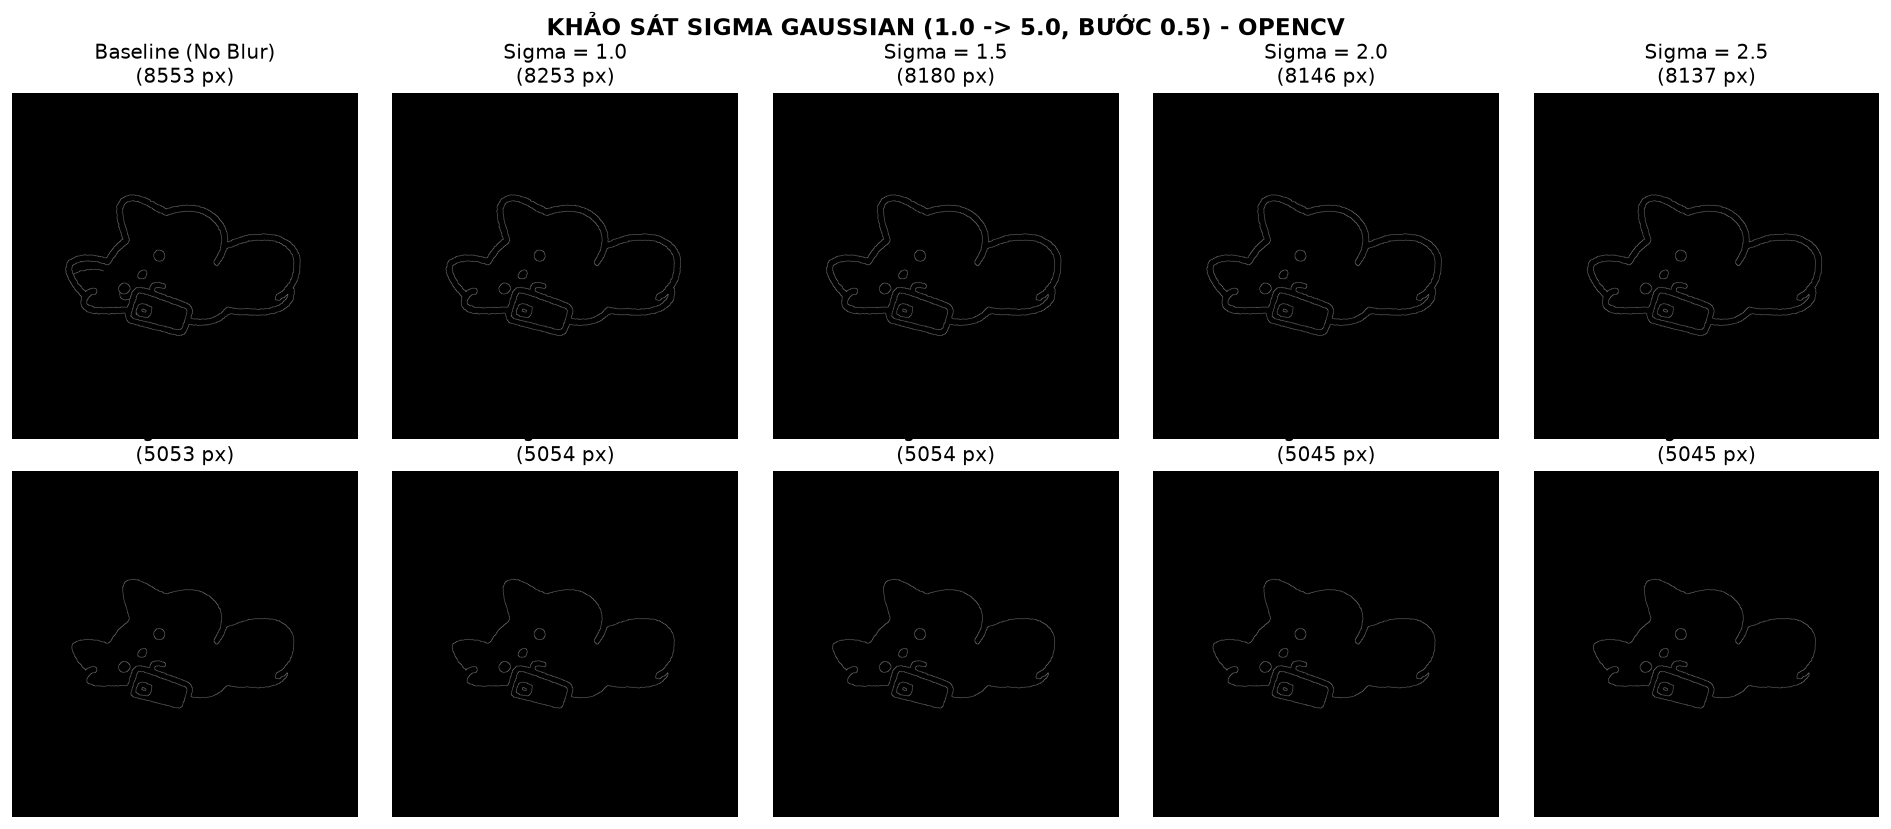

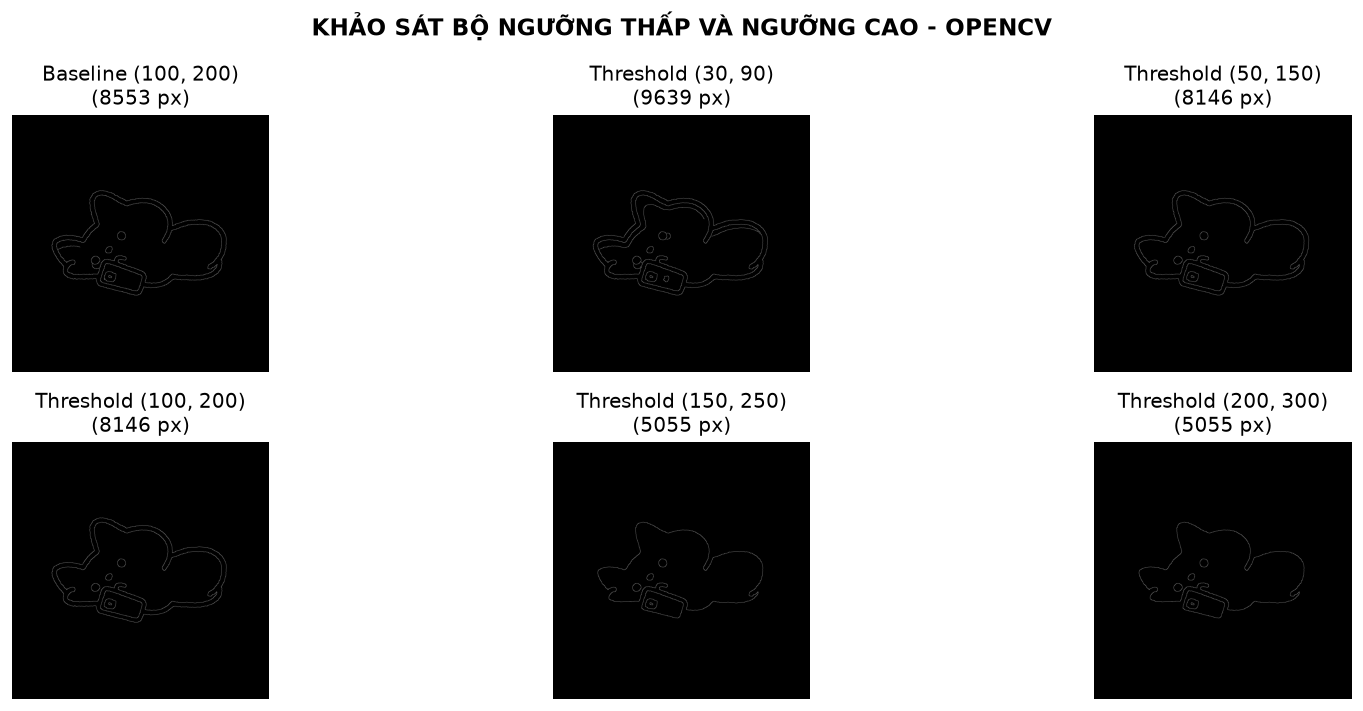

In [2]:
# 1. Baseline OpenCV Canny (100, 200)
edge_default = cv2.Canny(gray, 100, 200)
count_default = np.count_nonzero(edge_default)
print(f"--- CANNY MẶC ĐỊNH OPENCV (100, 200) ---")
print(f"Số pixel cạnh thu được: {count_default} pixels\n")

# 2. Khảo sát Sigma (1.0 -> 5.0, bước 0.5)
sigmas = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
edge_sigmas = []
count_sigmas = []

for s in sigmas:
    blur = cv2.GaussianBlur(gray, (5, 5), s)
    edge = cv2.Canny(blur, 100, 200)
    cnt = np.count_nonzero(edge)
    edge_sigmas.append(edge)
    count_sigmas.append(cnt)

# 3. Khảo sát Ngưỡng Low / High Threshold
blur_std = cv2.GaussianBlur(gray, (5, 5), 2.0)
threshold_pairs = [(30, 90), (50, 150), (100, 200), (150, 250), (200, 300)]
edge_thresholds = []
count_thresholds = []

for low, high in threshold_pairs:
    edge = cv2.Canny(blur_std, low, high)
    cnt = np.count_nonzero(edge)
    edge_thresholds.append(edge)
    count_thresholds.append(cnt)

# Trực quan hóa Subplots cho Duy
fig2, axes = plt.subplots(2, 5, figsize=(16, 7))
axes[0, 0].imshow(edge_default, cmap="gray")
axes[0, 0].set_title(f"Baseline (No Blur)\n({count_default} px)")
axes[0, 0].axis("off")

for idx, s in enumerate(sigmas):
    r, c = (idx + 1) // 5, (idx + 1) % 5
    axes[r, c].imshow(edge_sigmas[idx], cmap="gray")
    axes[r, c].set_title(f"Sigma = {s}\n({count_sigmas[idx]} px)")
    axes[r, c].axis("off")

plt.suptitle("KHẢO SÁT SIGMA GAUSSIAN (1.0 -> 5.0, BƯỚC 0.5) - OPENCV", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

fig3, axes = plt.subplots(2, 3, figsize=(15, 6))
axes[0, 0].imshow(edge_default, cmap="gray")
axes[0, 0].set_title(f"Baseline (100, 200)\n({count_default} px)")
axes[0, 0].axis("off")

for idx, (low, high) in enumerate(threshold_pairs):
    r, c = (idx + 1) // 3, (idx + 1) % 3
    axes[r, c].imshow(edge_thresholds[idx], cmap="gray")
    axes[r, c].set_title(f"Threshold ({low}, {high})\n({count_thresholds[idx]} px)")
    axes[r, c].axis("off")

plt.suptitle("KHẢO SÁT BỘ NGƯỠNG THẤP VÀ NGƯỠNG CAO - OPENCV", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


📊 **PHÂN TÍCH CHỈ SỐ ĐỊNH LƯỢNG VÀ KẾT QUẢ KHẢO SÁT OPENCV (DUY):**

1. **Khảo sát Sigma làm mờ Gaussian ($\sigma = 1.0 \to 5.0$):**
   - **Baseline (Không mờ):** `8,553 px` (Chứa nhiều đốm nhiễu hạt nhỏ).
   - **$\sigma = 1.0 \to 2.5$:** Số pixel giảm nhẹ từ `8,253 px` $\to$ `8,146 px`. Nhiễu hạt bị triệt tiêu hoàn toàn, đường viền vật thể duy trì độ sắc nét cao.
   - **$\sigma = 3.0 \to 5.0$:** Số pixel giảm đột ngột **~38%** xuống `5,053 px`. Chi tiết mảnh bị xóa hoàn toàn, vị trí đường biên bị dịch chuyển và biến dạng.
2. **Khảo sát Bộ Ngưỡng Low/High Threshold:**
   - **Threshold (30, 90):** `9,639 px` (Nạp thêm nhiều đường nét nhiễu mờ không mong muốn).
   - **Threshold (50, 150) & (100, 200):** `8,146 px` (**Vùng cân bằng vàng**).
   - **Threshold (150, 250) & (200, 300):** `5,055 px` (Rách biên, mất chi tiết cạnh yếu).

---


### 💻 PHẦN II.1 & II.2: CÀI ĐẶT CANNY BẰNG SCIKIT-IMAGE (PHƯỚC - TV 5)
Sử dụng thư viện `skimage.feature.canny` để trích xuất cạnh và khảo sát tham số `sigma`, `low_threshold`, `high_threshold`.


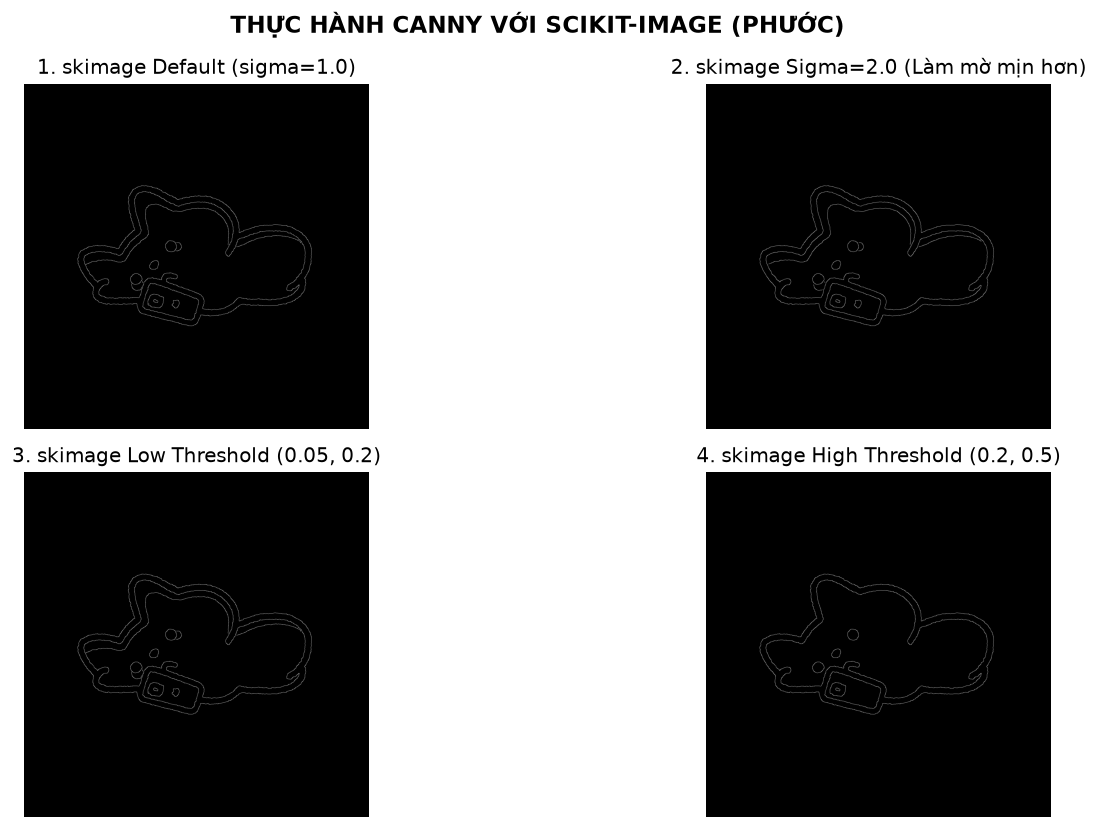

In [3]:
from skimage import feature, color

# skimage canny yêu cầu ảnh mức xám dạng float [0, 1]
gray_sk = gray.astype(np.float64) / 255.0

edge_sk_def = feature.canny(gray_sk, sigma=1.0)
edge_sk_s2 = feature.canny(gray_sk, sigma=2.0)
edge_sk_low = feature.canny(gray_sk, sigma=1.0, low_threshold=0.05, high_threshold=0.2)
edge_sk_high = feature.canny(gray_sk, sigma=1.0, low_threshold=0.2, high_threshold=0.5)

plt.figure(figsize=(14, 7))
plt.subplot(2, 2, 1)
plt.imshow(edge_sk_def, cmap="gray")
plt.title("1. skimage Default (sigma=1.0)")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(edge_sk_s2, cmap="gray")
plt.title("2. skimage Sigma=2.0 (Làm mờ mịn hơn)")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(edge_sk_low, cmap="gray")
plt.title("3. skimage Low Threshold (0.05, 0.2)")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(edge_sk_high, cmap="gray")
plt.title("4. skimage High Threshold (0.2, 0.5)")
plt.axis("off")

plt.suptitle("THỰC HÀNH CANNY VỚI SCIKIT-IMAGE (PHƯỚC)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


📊 **PHÂN TÍCH ĐÁNH GIÁ KẾT QUẢ SCIKIT-IMAGE (PHƯỚC):**
- Hàm `skimage.feature.canny` trả về ma trận **Boolean array** (`True/False`).
- Tăng `sigma=2.0` giúp triệt tiêu các vết xám mờ hiệu quả.
- Tùy chỉnh `low_threshold=0.05` giúp thu lại các nét cạnh mờ, trong khi `high_threshold=0.5` giúp lọc cực kỳ nghiêm ngặt chỉ giữ lại đường viền chính.

---


### 💻 PHẦN II.3: THỬ NGHIỆM CANNY TRÊN ĐA DẠNG LOẠI ẢNH (VINH - TV 6)
Thử nghiệm Canny trên 3 kịch bản ảnh thách thức thực tế:
1. **Ảnh nhiều nhiễu (Noisy Image):** Nhiễu hạt Gaussian.
2. **Ảnh độ tương phản thấp (Low Contrast Image):** Dải độ xám bị hẹp.
3. **Ảnh nhiều chi tiết (High Detail Image):** Hoa văn phức tạp.


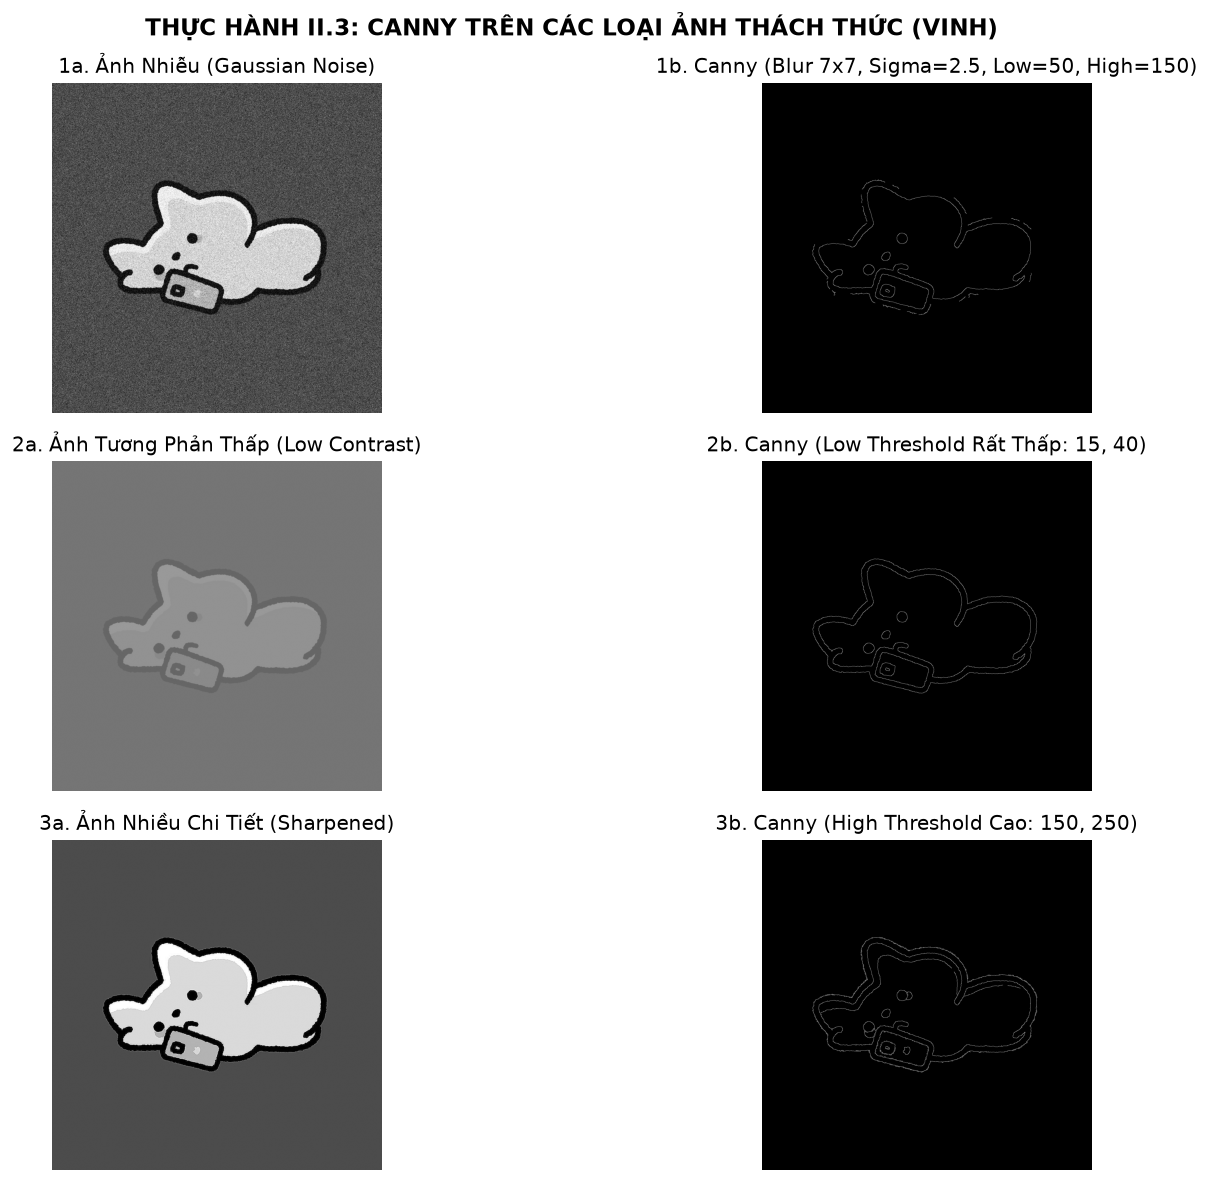

In [4]:
# a) Ảnh nhiều nhiễu Gaussian
noise = np.random.normal(0, 50, gray.shape).astype(np.float32)
img_noisy = np.clip(gray.astype(np.float32) + noise, 0, 255).astype(np.uint8)
blur_noisy = cv2.GaussianBlur(img_noisy, (7, 7), 2.5)
edges_noisy = cv2.Canny(blur_noisy, 50, 150)

# b) Ảnh tương phản thấp
img_low_contrast = np.clip((gray.astype(np.float32) - 128) * 0.2 + 128, 0, 255).astype(np.uint8)
blur_lc = cv2.GaussianBlur(img_low_contrast, (5, 5), 1.0)
edges_low_contrast = cv2.Canny(blur_lc, 15, 40)

# c) Ảnh nhiều chi tiết (Sharpened)
kernel_sharpen = np.array([[-1,-1,-1], [-1, 9,-1], [-1,-1,-1]])
img_detailed = cv2.filter2D(gray, -1, kernel_sharpen)
blur_det = cv2.GaussianBlur(img_detailed, (3, 3), 1.0)
edges_detailed = cv2.Canny(blur_det, 150, 250)

plt.figure(figsize=(15, 10))
plt.subplot(3, 2, 1)
plt.imshow(img_noisy, cmap="gray")
plt.title("1a. Ảnh Nhiễu (Gaussian Noise)")
plt.axis("off")

plt.subplot(3, 2, 2)
plt.imshow(edges_noisy, cmap="gray")
plt.title("1b. Canny (Blur 7x7, Sigma=2.5, Low=50, High=150)")
plt.axis("off")

plt.subplot(3, 2, 3)
plt.imshow(img_low_contrast, cmap="gray", vmin=0, vmax=255)
plt.title("2a. Ảnh Tương Phản Thấp (Low Contrast)")
plt.axis("off")

plt.subplot(3, 2, 4)
plt.imshow(edges_low_contrast, cmap="gray")
plt.title("2b. Canny (Low Threshold Rất Thấp: 15, 40)")
plt.axis("off")

plt.subplot(3, 2, 5)
plt.imshow(img_detailed, cmap="gray")
plt.title("3a. Ảnh Nhiều Chi Tiết (Sharpened)")
plt.axis("off")

plt.subplot(3, 2, 6)
plt.imshow(edges_detailed, cmap="gray")
plt.title("3b. Canny (High Threshold Cao: 150, 250)")
plt.axis("off")

plt.suptitle("THỰC HÀNH II.3: CANNY TRÊN CÁC LOẠI ẢNH THÁCH THỨC (VINH)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


📊 **PHÂN TÍCH KẾT QUẢ CẠNH TRÊN 3 LOẠI ẢNH THÁCH THỨC (VINH):**
1. **Ảnh Nhiễu (Noisy Image):** Bắt buộc làm mờ mạnh `GaussianBlur(7,7)` và `sigma=2.5` để dập tắt nhiễu hạt trước khi qua Canny.
2. **Ảnh Tương Phản Thấp (Low Contrast):** Gradient nhỏ đòi hỏi hạ bộ ngưỡng Canny xuống rất thấp `(15, 40)` để trích xuất được biên mờ.
3. **Ảnh Nhiều Chi Tiết (High Detail):** Hoa văn rác nhiều đòi hỏi tăng High Threshold lên `(150, 250)` để loại bỏ các đường nét vụn vặt.

---


### 💻 PHẦN II.4: KẾT HỢP CANNY VỚI PHÂN ĐOẠN CONTOUR VÀ HOUGH TRANSFORM (HUY - TV 7)
Ứng dụng đầu ra của Canny để trích xuất **Khung bao đối tượng (Bounding Box)** và nhận dạng **Đường thẳng/Đường tròn (Hough Lines & Circles)**.


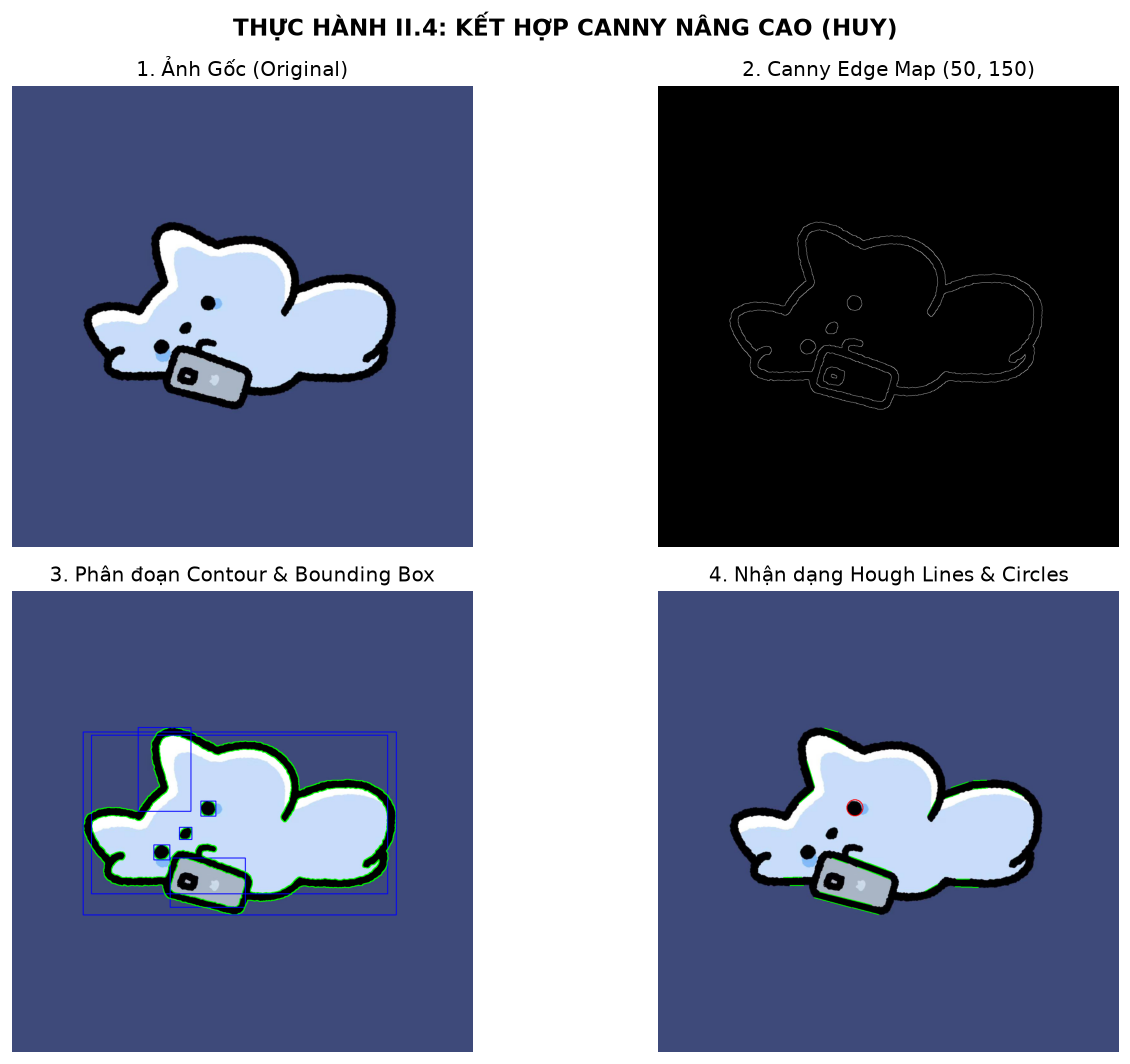

In [5]:
canny_base = cv2.Canny(blur_std, 50, 150)

# 1. Phân đoạn Contour & Bounding Box
contours, _ = cv2.findContours(canny_base, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
img_contour = img.copy()

for cnt in contours:
    if cv2.contourArea(cnt) > 50:
        cv2.drawContours(img_contour, [cnt], -1, (0, 255, 0), 2)
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(img_contour, (x, y), (x + w, y + h), (255, 0, 0), 2)

# 2. Nhận dạng Hough Transform
img_hough = img.copy()
lines = cv2.HoughLinesP(canny_base, 1, np.pi/180, threshold=50, minLineLength=40, maxLineGap=10)
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = map(int, line.flatten()[:4])
        cv2.line(img_hough, (x1, y1), (x2, y2), (0, 255, 0), 2)

circles = cv2.HoughCircles(blur_std, cv2.HOUGH_GRADIENT, dp=1, minDist=50, param1=150, param2=30, minRadius=20, maxRadius=100)
if circles is not None:
    circles = np.uint16(np.around(circles))
    for i in circles[0, :]:
        cv2.circle(img_hough, (i[0], i[1]), i[2], (0, 0, 255), 2)

plt.figure(figsize=(12, 9))
plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("1. Ảnh Gốc (Original)")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(canny_base, cmap="gray")
plt.title("2. Canny Edge Map (50, 150)")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(cv2.cvtColor(img_contour, cv2.COLOR_BGR2RGB))
plt.title("3. Phân đoạn Contour & Bounding Box")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(cv2.cvtColor(img_hough, cv2.COLOR_BGR2RGB))
plt.title("4. Nhận dạng Hough Lines & Circles")
plt.axis("off")

plt.suptitle("THỰC HÀNH II.4: KẾT HỢP CANNY NÂNG CAO (HUY)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


📊 **PHÂN TÍCH KẾT QUẢ KẾT HỢP ỨNG DỤNG NÂNG CAO (HUY):**
- **Contour & Bounding Box:** Bản đồ cạnh nhị phân Canny giúp `cv2.findContours()` trích xuất chính xác đường biên khép kín và vẽ khung bao chữ nhật Bounding Box ôm sát đối tượng.
- **Hough Transform:** Cạnh mỏng 1-pixel là tiền xử lý bắt buộc giúp `cv2.HoughLinesP()` và `cv2.HoughCircles()` trích xuất các đường thẳng và đường tròn hình học mà không bị nhầm nhiễu.

---


## 🎯 PHẦN III: KẾT LUẬN & ĐÁNH GIÁ TỔNG KẾT

1. **Chất lượng Canny:** Canny vượt trội hơn Sobel và Laplacian nhờ khả năng làm mỏng cạnh 1-pixel, chống nhiễu Gaussian và nối đường biên liên tục bằng Hysteresis.
2. **Ảnh hưởng Tham số:** 
   - $\sigma$ lớn giúp triệt nhiễu mạnh nhưng làm mờ và dịch chuyển vị trí cạnh.
   - Ngưỡng cao $T_{\text{high}}$ quyết định độ tin cậy cạnh mạnh; Ngưỡng thấp $T_{\text{low}}$ quyết định độ liên tục cạnh yếu. Tỷ lệ tối ưu khuyến nghị $2:1 \to 3:1$.
3. **Canny cho Ảnh màu:** Thường chuyển sang Grayscale hoặc xử lý độc lập từng kênh RGB/HSV/Lab rồi hợp nhất bằng phép toán logic `bitwise_or`.
4. **Canny cho Video thời gian thực:** Kết hợp lọc khử nhiễu thời gian (`cv2.addWeighted`), cắt ROI và tăng tốc GPU CUDA để đạt 30-60 FPS.
